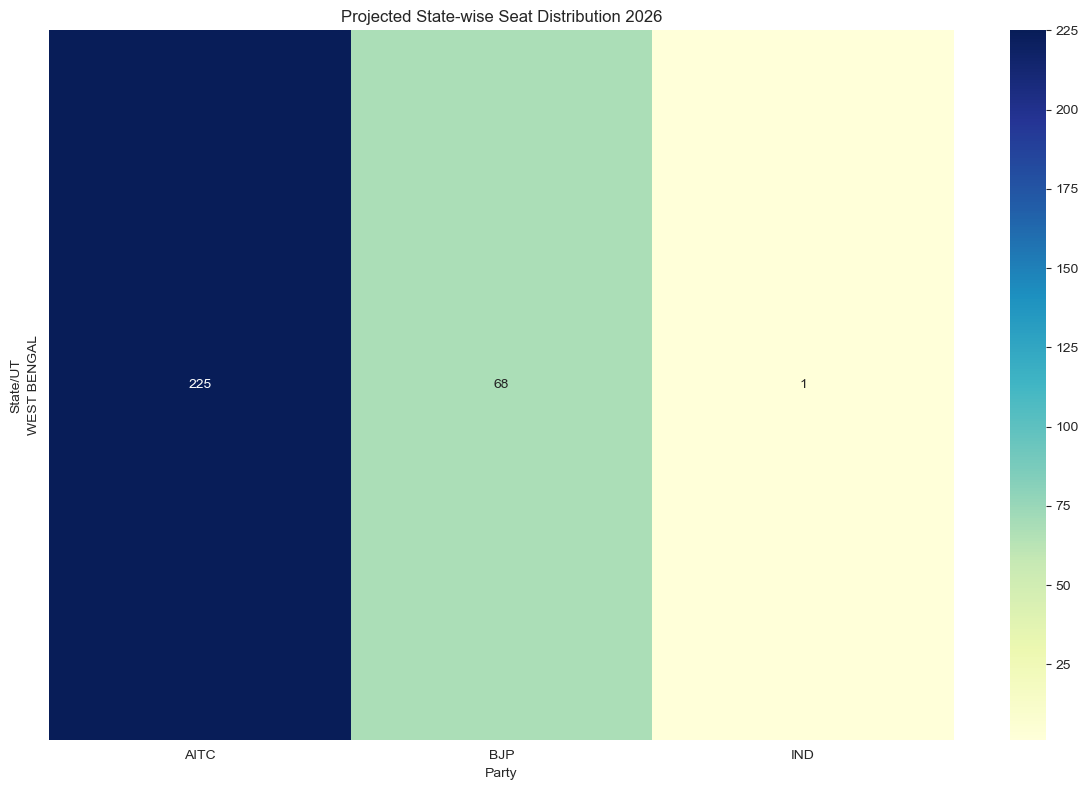

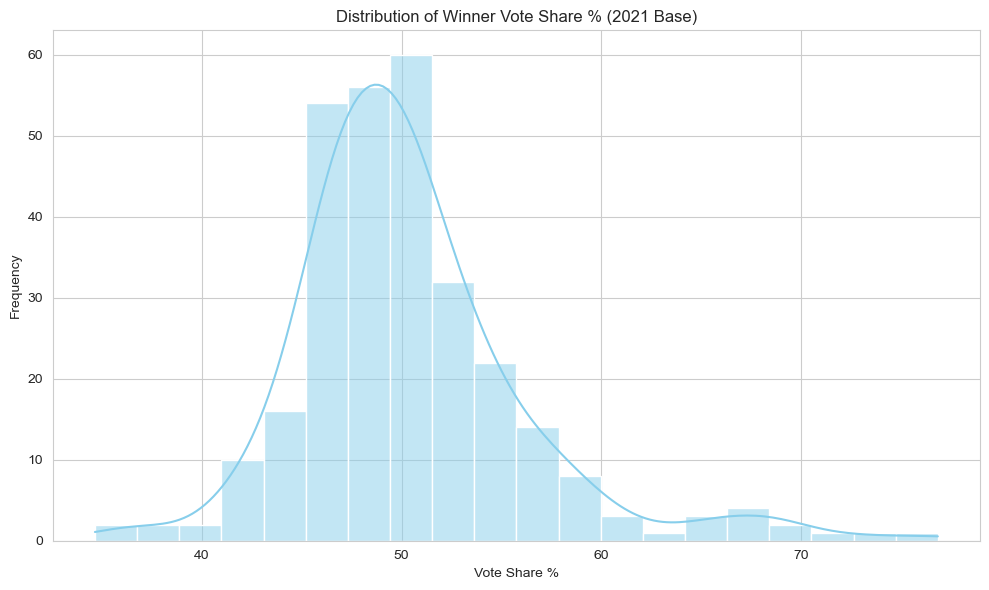

=== Sample 2026 Projection (first 5 constituencies) ===
  state_ut_name             ac_name predicted_party_2026 winner_party  \
0   WEST BENGAL           MEKLIGANJ                 AITC         AITC   
1   WEST BENGAL         MATHABHANGA                  BJP          BJP   
2   WEST BENGAL    COOCHBEHAR UTTAR                  BJP          BJP   
3   WEST BENGAL  COOCHBEHAR DAKSHIN                  BJP          BJP   
4   WEST BENGAL          SITALKUCHI                  BJP          BJP   

   winner_vote_share_pct  
0              49.982893  
1              52.869941  
2              49.395284  
3              46.832562  
4              50.801737  

=== Projected State-wise Seat Tally 2026 (first 10 rows) ===
  state_ut_name predicted_party_2026  projected_seats_2026
0   WEST BENGAL                 AITC                   225
1   WEST BENGAL                  BJP                    68
2   WEST BENGAL                  IND                     1


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import os

# Create output directory
os.makedirs("outputs_2026", exist_ok=True)

df = pd.read_csv("constituency_results_2021.csv")

# Fill missing vote shares if any
df['winner_vote_share_pct'] = df['winner_vote_share_pct'].fillna(0)
df['runner_up_vote_share_pct'] = df['runner_up_vote_share_pct'].fillna(0)
df['vote_margin_pct'] = df['vote_margin'] / df['total_votes_polled'] * 100

feature_cols = ['winner_vote_share_pct', 'runner_up_vote_share_pct', 'vote_margin_pct', 'num_candidates']
X = df[feature_cols]

le_party = LabelEncoder()
y = le_party.fit_transform(df['winner_party'])

# Train Random Forest on 2021 data
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)


np.random.seed(42)
# Random swing per constituency (-5% to +5%)
swing_pct = np.random.normal(0, 3, size=len(df))
X_2026 = X.copy()
X_2026['winner_vote_share_pct'] = np.clip(X_2026['winner_vote_share_pct'] + swing_pct, 0, 100)


df['predicted_party_encoded'] = rf.predict(X_2026)
df['predicted_party_2026'] = le_party.inverse_transform(df['predicted_party_encoded'])




# By State
state_seat_tally_2026 = df.groupby(['state_ut_name', 'predicted_party_2026']).size().reset_index(name='projected_seats_2026')
state_seat_tally_2026 = state_seat_tally_2026.sort_values(['state_ut_name', 'projected_seats_2026'], ascending=[True, False])
state_seat_tally_2026.to_csv("outputs_2026/state_seat_tally_2026.csv", index=False)

# Constituency-level
df.to_csv("outputs_2026/constituency_projection_2026.csv", index=False)


sns.set_style("whitegrid")


#State-wise Top Parties - Heatmap
state_pivot = state_seat_tally_2026.pivot(index='state_ut_name', columns='predicted_party_2026', values='projected_seats_2026').fillna(0)
plt.figure(figsize=(12,8))
sns.heatmap(state_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title("Projected State-wise Seat Distribution 2026")
plt.ylabel("State/UT")
plt.xlabel("Party")
plt.tight_layout()
plt.savefig("outputs_2026/state_seat_heatmap_2026.png")
plt.show()

# 5c: Party Vote Share Distribution (Histogram)
plt.figure(figsize=(10,6))
sns.histplot(df['winner_vote_share_pct'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Winner Vote Share % (2021 Base)")
plt.xlabel("Vote Share %")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs_2026/winner_vote_share_distribution.png")
plt.show()

# =========================
# Step 6: Summary Outputs
# =========================
print("=== Sample 2026 Projection (first 5 constituencies) ===")
print(df[['state_ut_name', 'ac_name', 'predicted_party_2026', 'winner_party', 'winner_vote_share_pct']].head())

print("\n=== Projected State-wise Seat Tally 2026 (first 10 rows) ===")
print(state_seat_tally_2026.head(10))
